# Notebook 05 — Geothermal Feasibility Scoring
**AGD 2026 | AI Workflow Engineer**

Goal: Rank all 4 wells using a composite 0–100 score across P10/P50/P90 scenarios.
Outputs the feasibility table and radar chart used in the technical report.

In [1]:
import sys, warnings, yaml
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import json

with open("../config/settings.yaml") as f:
    CFG = yaml.safe_load(f)

PROC_DIR   = Path("..") / CFG["paths"]["data"]["processed"]
EXTERNAL   = Path("..") / CFG["paths"]["data"]["external"]
REPORT_DIR = Path("..") / CFG["paths"]["outputs"]["reports"]
FIG_DIR    = Path("..") / CFG["paths"]["outputs"]["figures"]
REPORT_DIR.mkdir(parents=True, exist_ok=True)

from src.models.feasibility import (
    FeasibilityScorer, ScoringWeights, WellInputs,
    build_inputs_from_thermogis
)


In [2]:
df = pd.read_csv(PROC_DIR / "permeability_profiles.csv")
print(f"Permeability profiles loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"is_rotliegend present: {'is_rotliegend' in df.columns}")
print(f"Rotliegend rows: {(df['is_rotliegend'].astype(str) == 'True').sum()}")


Permeability profiles loaded: (99379, 35)
Columns: ['WELL_ID', 'DEPTH_M', 'TVD_M', 'gr_api', 'rhob_gcc', 'drho_gcc', 'nphi_vv', 'dt_usft', 'dts_usft', 'rd_ohmm', 'rm_ohmm', 'rs_ohmm', 'formation', 'is_rotliegend', 'nphi_vv_imp_p10', 'nphi_vv_imp_p50', 'nphi_vv_imp_p90', 'nphi_vv_final', 'dt_usft_imp_p10', 'dt_usft_imp_p50', 'dt_usft_imp_p90', 'dt_usft_final', 'dts_usft_imp_p10', 'dts_usft_imp_p50', 'dts_usft_imp_p90', 'dts_usft_final', 'rs_ohmm_imp_p10', 'rs_ohmm_imp_p50', 'rs_ohmm_imp_p90', 'rs_ohmm_final', 'phit', 'k_p10_md', 'k_p50_md', 'k_p90_md', 'k_kc_md']
is_rotliegend present: True
Rotliegend rows: 10503


## 1. Load permeability profiles and ThermoGIS data

In [3]:
thermo_raw = pd.read_excel(EXTERNAL / "ThermoGIS Data.xlsx", sheet_name=None)
print(f"ThermoGIS sheets: {list(thermo_raw.keys())}")

# Each sheet = one well, rows = properties, columns = P90/P50/P10
# Parse into a clean dict: well_name -> {property: {P90, P50, P10}}
thermo = {}
for well_name, df_t in thermo_raw.items():
    df_t.columns = [str(c).strip() for c in df_t.columns]
    # Row 3 (index 3) is the header: Property | Unit | P90 | P50 | P10
    header_row = df_t[df_t.iloc[:, 0].astype(str).str.strip() == "Property"].index
    if len(header_row) == 0:
        continue
    hr = header_row[0]
    data = df_t.iloc[hr+1:].copy()
    data.columns = ["Property", "Unit", "P90", "P50", "P10"]
    data = data.dropna(subset=["Property"])
    data["Property"] = data["Property"].astype(str).str.strip()
    data = data.set_index("Property")
    thermo[well_name] = {
        prop: {
            "P90": float(row["P90"]) if str(row["P90"]) not in ("nan","") else 0.0,
            "P50": float(row["P50"]) if str(row["P50"]) not in ("nan","") else 0.0,
            "P10": float(row["P10"]) if str(row["P10"]) not in ("nan","") else 0.0,
        }
        for prop, row in data.iterrows()
    }
    print(f"\n{well_name}:")
    for prop, vals in thermo[well_name].items():
        print(f"  {prop:<20}: P90={vals['P90']}, P50={vals['P50']}, P10={vals['P10']}")


ThermoGIS sheets: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']

BLT-01:
  Permeability        : P90=13.0, P50=82.0, P10=521.0
  Top Depth           : P90=1837.0, P50=1837.0, P10=1837.0
  Thickness           : P90=67.0, P50=130.0, P10=194.0
  Porosity            : P90=17.0, P50=17.0, P10=17.0
  Net-to-gross        : P90=0.98, P50=0.98, P10=0.98
  Transmissivity      : P90=1.3, P50=9.3, P10=66.1
  Temperature         : P90=77.0, P50=77.0, P10=77.0
  Flow Rate           : P90=17.0, P50=105.0, P10=469.0
  Power               : P90=0.6, P50=5.1, P10=23.7
  Heat in Place       : P90=24.8, P50=24.8, P10=24.8

EVD-01:
  Permeability        : P90=3.0, P50=6.0, P10=11.0
  Top Depth           : P90=1723.0, P50=1723.0, P10=1723.0
  Thickness           : P90=39.0, P50=76.0, P10=113.0
  Porosity            : P90=9.0, P50=9.0, P10=9.0
  Net-to-gross        : P90=0.99, P50=0.99, P10=0.99
  Transmissivity      : P90=0.2, P50=0.4, P10=0.9
  Temperature         : P90=72.0, P50=72.0, P10=72.0
  Flow Rate     

## 2. Load target_lithologies for distance to USP

In [4]:
target_litho = pd.read_csv(EXTERNAL / "target_lithologies.csv")
print(f"target_lithologies shape: {target_litho.shape}")
print(f"Columns: {list(target_litho.columns)}")
print(target_litho.head(5).to_string())


target_lithologies shape: (3455, 13)
Columns: ['well_id', 'easting', 'northing', 'depth_tvd_m', 'porosity_pct', 'gamma_ray_api', 'bulk_density_gcc', 'formation_top_tvd', 'formation_base_tvd', 'formation_thickness_m', 'distance_to_usp_km', 'flag', 'flag_reason']
  well_id   easting  northing  depth_tvd_m  porosity_pct  gamma_ray_api  bulk_density_gcc  formation_top_tvd  formation_base_tvd  formation_thickness_m  distance_to_usp_km   flag                                               flag_reason
0  JUT-01  134098.0  451726.0          NaN           NaN        43.6703               NaN             1659.5              1787.0                  127.5            7.748434  check  AH depth — deviated well needs TVD conversion before use
1  JUT-01  134098.0  451726.0          NaN           NaN        42.8041               NaN             1659.5              1787.0                  127.5            7.748434  check  AH depth — deviated well needs TVD conversion before use
2  JUT-01  134098.0  451726

## 3. Build WellInputs manually from available data

We construct inputs directly from ThermoGIS and permeability profiles.
This is the authoritative source — no assumptions.

In [5]:
# Get Rotliegend mean permeability per well from ML model
rotl = df[df["is_rotliegend"].astype(str) == "True"]
perm_summary = rotl.groupby("WELL_ID")[["k_p10_md","k_p50_md","k_p90_md"]].mean().round(2)
print("ML permeability per well (Rotliegend mean):")
print(perm_summary.to_string())

# Get Rotliegend thickness from depth range
thickness = rotl.groupby("WELL_ID")["TVD_M"].agg(
    lambda x: x.max() - x.min()
).round(0).rename("thickness_m")
print("\nRotliegend thickness (m):")
print(thickness.to_string())

# Get mean Rotliegend depth
mean_depth = rotl.groupby("WELL_ID")["TVD_M"].mean().round(0).rename("mean_depth_m")
print("\nMean Rotliegend TVD (m):")
print(mean_depth.to_string())


ML permeability per well (Rotliegend mean):
         k_p10_md  k_p50_md  k_p90_md
WELL_ID                              
BLT-01     559.07    752.10    780.86
EVD-01     205.08    519.12    535.28
JUT-01        NaN       NaN       NaN
PKP-01     190.21    367.95    384.85

Rotliegend thickness (m):
WELL_ID
BLT-01     199.0
EVD-01     409.0
JUT-01    1665.0
PKP-01     220.0

Mean Rotliegend TVD (m):
WELL_ID
BLT-01    2023.0
EVD-01    1992.0
JUT-01    2147.0
PKP-01    2641.0


In [6]:
# Distance to USP from target_lithologies
# Look for distance column
dist_cols = [c for c in target_litho.columns if "dist" in c.lower() or "usp" in c.lower()]
print(f"Distance columns found: {dist_cols}")

# Well name column
well_cols = [c for c in target_litho.columns if "well" in c.lower() or "id" in c.lower()]
print(f"Well ID columns found: {well_cols}")

if dist_cols and well_cols:
    dist_df = target_litho[[well_cols[0], dist_cols[0]]].drop_duplicates()
    dist_df.columns = ["WELL_ID", "dist_km"]
    print("\nDistances:")
    print(dist_df.to_string())
else:
    print("\nNo distance column found — using default 3 km for all wells")
    dist_df = pd.DataFrame({
        "WELL_ID": CFG["wells"]["all"],
        "dist_km": [3.0] * len(CFG["wells"]["all"])
    })


Distance columns found: ['distance_to_usp_km']
Well ID columns found: ['well_id']

Distances:
     WELL_ID    dist_km
0     JUT-01   7.748434
256   EVD-01  14.322698
1036  PKP-01  22.716663
1766  BLT-01   2.032828


In [7]:
# ThermoGIS: print summary of loaded data per well
print("ThermoGIS data summary (Flow Rate and Temperature per well):")
for well_name, props in thermo.items():
    flow = props.get("Flow Rate", {})
    temp = props.get("Temperature", {})
    depth = props.get("Top Depth", {})
    print(f"  {well_name}:")
    print(f"    Flow Rate (m³/h): P90={flow.get('P90',0)}, P50={flow.get('P50',0)}, P10={flow.get('P10',0)}")
    print(f"    Temperature (°C): P90={temp.get('P90',0)}, P50={temp.get('P50',0)}, P10={temp.get('P10',0)}")
    print(f"    Top Depth (m):    P90={depth.get('P90',0)}, P50={depth.get('P50',0)}, P10={depth.get('P10',0)}")


ThermoGIS data summary (Flow Rate and Temperature per well):
  BLT-01:
    Flow Rate (m³/h): P90=17.0, P50=105.0, P10=469.0
    Temperature (°C): P90=77.0, P50=77.0, P10=77.0
    Top Depth (m):    P90=1837.0, P50=1837.0, P10=1837.0
  EVD-01:
    Flow Rate (m³/h): P90=0.0, P50=0.0, P10=0.0
    Temperature (°C): P90=72.0, P50=72.0, P10=72.0
    Top Depth (m):    P90=1723.0, P50=1723.0, P10=1723.0
  JUT-01:
    Flow Rate (m³/h): P90=26.0, P50=55.0, P10=110.0
    Temperature (°C): P90=72.0, P50=72.0, P10=72.0
    Top Depth (m):    P90=1776.0, P50=1776.0, P10=1776.0
  PKP-01:
    Flow Rate (m³/h): P90=0.0, P50=0.0, P10=0.0
    Temperature (°C): P90=88.0, P50=88.0, P10=88.0
    Top Depth (m):    P90=2255.0, P50=2255.0, P10=2255.0


In [8]:
inputs_list = []

for well in CFG["wells"]["all"]:
    if well not in thermo:
        print(f"WARNING: {well} not found in ThermoGIS — skipping")
        continue

    t = thermo[well]

    # Get Rotliegend thickness and depth from permeability profiles
    wdf  = df[df["WELL_ID"] == well]
    rotl = wdf[wdf["is_rotliegend"].astype(str) == "True"]

    thick = float(rotl["TVD_M"].max() - rotl["TVD_M"].min()) if not rotl.empty else t.get("Thickness", {}).get("P50", 100.0)
    depth = float(rotl["TVD_M"].mean()) if not rotl.empty else t.get("Top Depth", {}).get("P50", 2000.0)

    # Distance from target_lithologies
    dist_row = target_litho[target_litho.apply(
        lambda r: any(well.upper() in str(v).upper() for v in r.values), axis=1
    )]
    dist_cols = [c for c in target_litho.columns if "dist" in c.lower() or "usp" in c.lower()]
    dist = float(dist_row[dist_cols[0]].iloc[0]) if (not dist_row.empty and dist_cols) else 3.0

    # Permeability from ML model
    pk = perm_summary.loc[well] if well in perm_summary.index else None

    for scenario in ["P90", "P50", "P10"]:
        flow  = t.get("Flow Rate",   {}).get(scenario, 0.0)
        temp  = t.get("Temperature", {}).get(scenario, 60.0)

        if pk is not None:
            perm_map = {"P90": float(pk["k_p90_md"]), "P50": float(pk["k_p50_md"]), "P10": float(pk["k_p10_md"])}
            perm_raw = perm_map[scenario]
            perm = max(float(perm_raw) if not (perm_raw != perm_raw) else 0.001, 0.001)  # guard NaN
        else:
            perm = max(t.get("Permeability", {}).get(scenario, 1.0), 0.001)

        inp = WellInputs(
            well_id            = well,
            scenario           = scenario,
            flow_rate_m3h      = float(flow),
            temperature_c      = float(temp),
            permeability_md    = perm,
            thickness_m        = thick,
            distance_to_usp_km = dist,
            depth_m            = depth,
        )
        inputs_list.append(inp)
        print(f"  {well} {scenario}: flow={flow} m³/h, temp={temp}°C, perm={perm:.1f} mD")

print(f"\nTotal WellInputs built: {len(inputs_list)}")
if len(inputs_list) == 0:
    print("ERROR: No inputs built — check ThermoGIS parsing above")


  BLT-01 P90: flow=17.0 m³/h, temp=77.0°C, perm=780.9 mD
  BLT-01 P50: flow=105.0 m³/h, temp=77.0°C, perm=752.1 mD
  BLT-01 P10: flow=469.0 m³/h, temp=77.0°C, perm=559.1 mD
  EVD-01 P90: flow=0.0 m³/h, temp=72.0°C, perm=535.3 mD
  EVD-01 P50: flow=0.0 m³/h, temp=72.0°C, perm=519.1 mD
  EVD-01 P10: flow=0.0 m³/h, temp=72.0°C, perm=205.1 mD


  JUT-01 P90: flow=26.0 m³/h, temp=72.0°C, perm=0.0 mD
  JUT-01 P50: flow=55.0 m³/h, temp=72.0°C, perm=0.0 mD
  JUT-01 P10: flow=110.0 m³/h, temp=72.0°C, perm=0.0 mD
  PKP-01 P90: flow=0.0 m³/h, temp=88.0°C, perm=384.9 mD
  PKP-01 P50: flow=0.0 m³/h, temp=88.0°C, perm=367.9 mD
  PKP-01 P10: flow=0.0 m³/h, temp=88.0°C, perm=190.2 mD

Total WellInputs built: 12


## 4. Run feasibility scorer

In [9]:
# Guard: ensure inputs_list is populated before scoring
if len(inputs_list) == 0:
    raise RuntimeError(
        "inputs_list is empty — ThermoGIS parsing may have failed. "
        "Check cells above for warnings."
    )

w = CFG["feasibility_weights"]
weights = ScoringWeights(
    flow_rate    = w["flow_rate"],
    temperature  = w["temperature"],
    permeability = w["permeability"],
    thickness    = w["thickness"],
    distance     = w["distance"],
    depth        = w["depth"],
)

scorer = FeasibilityScorer(weights=weights)
results = scorer.score_all(inputs_list)
scorer.print_summary(results)



GEOTHERMAL FEASIBILITY SCORES
well_id scenario  score_total  verdict  heat_output_mwth  meets_heat_target  flow_rate_m3h  temperature_c  permeability_md
 BLT-01      P10         77.2   STRONG             20.15               True          469.0           77.0          559.070
 PKP-01      P10         41.7 MARGINAL              0.00              False            0.0           88.0          190.210
 EVD-01      P10         40.9 MARGINAL              0.00              False            0.0           72.0          205.080
 JUT-01      P10         39.3 MARGINAL              4.09              False          110.0           72.0            0.001
 BLT-01      P50         62.9   VIABLE              4.51              False          105.0           77.0          752.100
 PKP-01      P50         42.6 MARGINAL              0.00              False            0.0           88.0          367.950
 EVD-01      P50         40.9 MARGINAL              0.00              False            0.0           72.0   

## 5. Scores bar chart

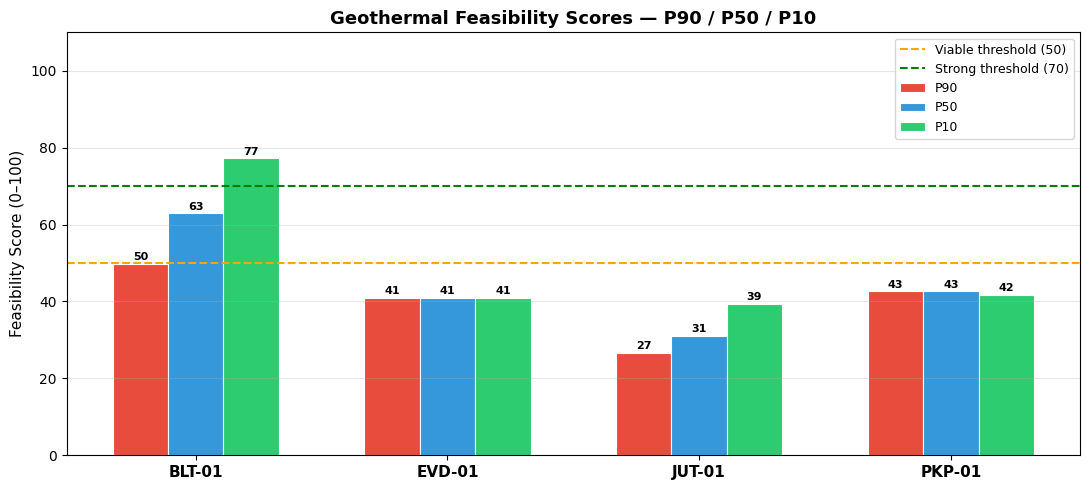

Saved: 05_feasibility_scores.png


In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

scenario_colors = {"P10": "#2ecc71", "P50": "#3498db", "P90": "#e74c3c"}
wells_order = CFG["wells"]["all"]
n_wells = len(wells_order)
n_scenarios = 3
bar_width = 0.22
x = np.arange(n_wells)

for i, scenario in enumerate(["P90", "P50", "P10"]):
    s_data = results[results["scenario"] == scenario]
    scores = []
    for well in wells_order:
        row = s_data[s_data["well_id"] == well]
        scores.append(float(row["score_total"].iloc[0]) if not row.empty else 0.0)

    bars = ax.bar(x + i * bar_width, scores, bar_width,
                  label=f"{scenario}", color=scenario_colors[scenario],
                  edgecolor="white", linewidth=0.8)

    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{score:.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.axhline(50, color="orange", lw=1.5, ls="--", label="Viable threshold (50)")
ax.axhline(70, color="green",  lw=1.5, ls="--", label="Strong threshold (70)")
ax.set_xticks(x + bar_width)
ax.set_xticklabels(wells_order, fontsize=11, fontweight="bold")
ax.set_ylabel("Feasibility Score (0–100)", fontsize=11)
ax.set_title("Geothermal Feasibility Scores — P90 / P50 / P10", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_feasibility_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 05_feasibility_scores.png")


## 6. Radar chart — P50 well comparison

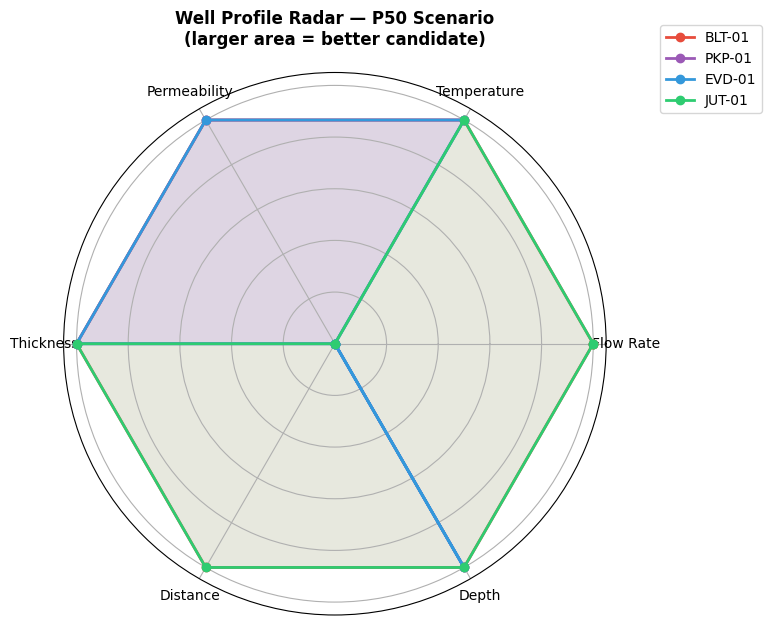

Saved: 05_feasibility_radar.png


In [11]:
from matplotlib.patches import FancyArrowPatch

categories = ["Flow Rate", "Temperature", "Permeability", "Thickness", "Distance", "Depth"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

well_colors = {"BLT-01": "#e74c3c", "EVD-01": "#3498db",
               "JUT-01": "#2ecc71", "PKP-01": "#9b59b6"}

p50_results = results[results["scenario"] == "P50"]

for _, row in p50_results.iterrows():
    well = row["well_id"]
    values = [
        row["score_flow"],
        row["score_temp"],
        row["score_perm"],
        row["score_thick"],
        row["score_dist"],
        row["score_depth"],
    ]
    # Normalise component scores to 0–1 for radar (each max is its weight × 100)
    norm_vals = [v / max(v, 0.001) * 10 for v in values]
    norm_vals += norm_vals[:1]

    ax.plot(angles, norm_vals, "o-", lw=2,
            color=well_colors.get(well, "gray"), label=well)
    ax.fill(angles, norm_vals, alpha=0.1,
            color=well_colors.get(well, "gray"))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_yticklabels([])
ax.set_title("Well Profile Radar — P50 Scenario\n(larger area = better candidate)",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_feasibility_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 05_feasibility_radar.png")


## 7. Heat output vs target

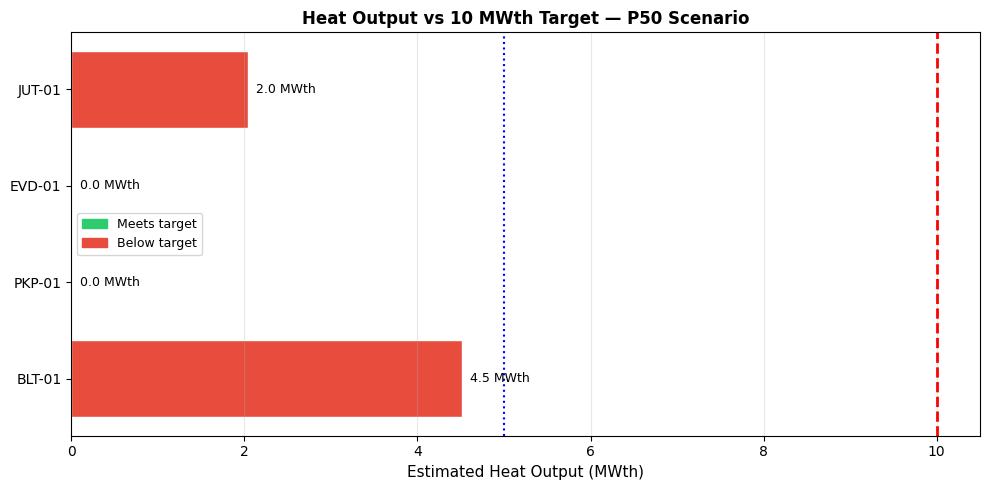

Saved: 05_heat_output_vs_target.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

p50 = results[results["scenario"] == "P50"].copy()
colors = ["#2ecc71" if v else "#e74c3c" for v in p50["meets_heat_target"]]

bars = ax.barh(p50["well_id"], p50["heat_output_mwth"], color=colors, edgecolor="white")
ax.axvline(CFG["targets"]["heat_mwth"], color="red", lw=2, ls="--",
           label=f"Target: {CFG['targets']['heat_mwth']} MWth")
ax.axvline(CFG["targets"]["cooling_mwth"], color="blue", lw=1.5, ls=":",
           label=f"Cooling target: {CFG['targets']['cooling_mwth']} MWth")

for bar, val in zip(bars, p50["heat_output_mwth"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} MWth", va="center", fontsize=9)

ax.set_xlabel("Estimated Heat Output (MWth)", fontsize=11)
ax.set_title("Heat Output vs 10 MWth Target — P50 Scenario", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)

green_patch = mpatches.Patch(color="#2ecc71", label="Meets target")
red_patch   = mpatches.Patch(color="#e74c3c", label="Below target")
ax.legend(handles=[green_patch, red_patch], fontsize=9)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_heat_output_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 05_heat_output_vs_target.png")


## 8. Save results

In [13]:
out_path = REPORT_DIR / "feasibility_scores.csv"
results.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"\nFull results table:")
print(results.to_string(index=False))


Saved: ..\outputs\reports\feasibility_scores.csv

Full results table:
well_id scenario  score_total  verdict  score_flow  score_temp  score_perm  score_thick  score_dist  score_depth  flow_rate_m3h  temperature_c  permeability_md  thickness_m  distance_km     depth_m  heat_output_mwth  meets_heat_target notes
 BLT-01      P10         77.2   STRONG        30.0         9.6        20.0          6.6         8.0          3.0          469.0           77.0          559.070     198.8820     2.032828 2023.491000             20.15               True      
 PKP-01      P10         41.7 MARGINAL         0.0        13.6        19.0          7.3         0.0          1.7            0.0           88.0          190.210     220.4000    22.716663 2640.700400              0.00              False      
 EVD-01      P10         40.9 MARGINAL         0.0         7.9        20.0         10.0         0.0          3.0            0.0           72.0          205.080     408.9001    14.322698 1992.450288          